# 🔍 Credit Card Fraud Detection

**Dataset:** [Credit Card Fraud Detection — Kaggle](https://www.kaggle.com/datasets/mlg-ulb/creditcardfraud)  
**Records:** 284,807 transactions · 31 features  
**Tools:** Python · pandas · scikit-learn · matplotlib

---

## 🎯 Project Goal

Detect fraudulent credit card transactions using anomaly detection.  
Real anonymized data from European cardholders (September 2013).

---

## 📋 Contents

1. Setup & Data Loading  
2. Class Imbalance  
3. Transaction Amount Analysis  
4. Visualisation: Normal vs Fraud  
5. Isolation Forest — 6 features  
6. Model Evaluation  
7. Isolation Forest — all 30 features  
8. Business Conclusion

## 1. Setup & Data Loading

Columns V1–V28 are PCA-transformed features (anonymized for confidentiality).  
Only `Amount` and `Time` are original. `Class` is the target: 0 = normal, 1 = fraud.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats
from sklearn.ensemble import IsolationForest

df = pd.read_csv('creditcard.csv')
df.shape

(284807, 31)

## 2. Class Imbalance

How many transactions are actually fraudulent?

In [2]:
df['Class'].value_counts(normalize=True).round(4)

,proportion
Class,
0,0.9983
1,0.0017


**Result:** Only 0.17% of transactions are fraudulent — extreme class imbalance.  
⚠️ A model that always predicts "normal" would be 99.83% accurate but completely useless.  
We use **precision, recall, and F1-score** instead of accuracy.

## 3. Transaction Amount: Normal vs Fraud

Do fraudulent transactions have different amounts than normal ones?

In [3]:
fraud    = df[df['Class'] == 1]['Amount']
normal   = df[df['Class'] == 0]['Amount']

print(f"Fraud   — mean: ${fraud.mean():.2f}, median: ${fraud.median():.2f}")
print(f"Normal  — mean: ${normal.mean():.2f}, median: ${normal.median():.2f}")

Fraud   — mean: $122.21, median: $9.25
Normal  — mean: $88.29, median: $22.00


**Key insight:**
- Fraud median: $9 vs Normal median: $22
- Fraud mean: $122 — pulled up by a few large fraudulent charges
- Pattern: fraudsters first test with a small amount, then charge a large one

## 4. Visualisation: Median Amount by Class

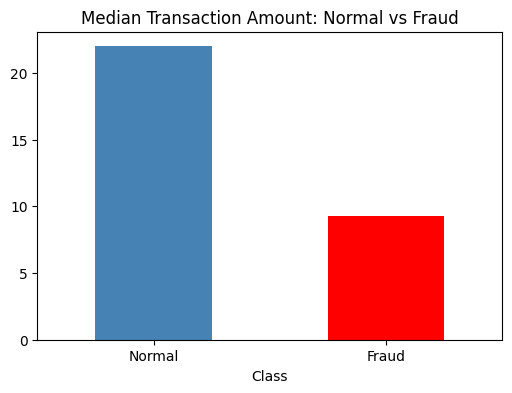

In [4]:
df.groupby('Class')['Amount'].median().plot(kind='bar', color=['steelblue','red'], figsize=(6,4), title='Median Transaction Amount: Normal vs Fraud')
plt.xticks([0,1], ['Normal','Fraud'], rotation=0)
plt.show()

## 5. Isolation Forest — 6 Features

**How Isolation Forest works:**  
Normal points are surrounded by similar points — hard to isolate.  
Anomalies stand alone — isolated quickly with fewer splits.  
The algorithm exploits this difference to flag anomalies.

`contamination=0.002` — we tell the model to expect ~0.2% anomalies  
(slightly above the real 0.17% — better to flag extra than miss fraud)

**Model 1:** uses only Amount + V1–V5 (6 features)

In [5]:
model = IsolationForest(contamination=0.002, random_state=42)
df['anomaly'] = model.fit_predict(df[['Amount', 'V1', 'V2', 'V3', 'V4', 'V5']])

# -1 = аномалия, 1 = нормально
df['anomaly'] = df['anomaly'].map({1: 0, -1: 1})
df['anomaly'].value_counts()

,count
anomaly,
0,284237
1,570


## 6. Model Evaluation

**Metrics explained:**
- **Precision** — of all transactions flagged as fraud, how many are actually fraud?
- **Recall** — of all real fraud cases, how many did the model catch?
- **F1-score** — balance between precision and recall

⚠️ In fraud detection, **Recall matters most** — missing a fraudster is worse than a false alarm.

In [6]:
from sklearn.metrics import classification_report

print(classification_report(df['Class'], df['anomaly']))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00    284315
           1       0.17      0.20      0.18       492

    accuracy                           1.00    284807
   macro avg       0.58      0.60      0.59    284807
weighted avg       1.00      1.00      1.00    284807



**Result (6 features):** Recall 20% — catches only 1 in 5 fraudsters.  
Limited features = limited detection power.

## 7. Isolation Forest — All 30 Features

**Model 2:** uses all available features (V1–V28 + Amount + Time)

In [7]:
features = [c for c in df.columns if c not in ['Class', 'anomaly']]

model2 = IsolationForest(contamination=0.002, random_state=42)
df['anomaly2'] = model2.fit_predict(df[features])
df['anomaly2'] = df['anomaly2'].map({1: 0, -1: 1})

print(classification_report(df['Class'], df['anomaly2']))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00    284315
           1       0.24      0.28      0.26       492

    accuracy                           1.00    284807
   macro avg       0.62      0.64      0.63    284807
weighted avg       1.00      1.00      1.00    284807



**Comparison:**

| Model | Features | Precision | Recall | F1 |
|-------|----------|-----------|--------|----|
| Model 1 | 6 | 0.17 | 0.20 | 0.18 |
| Model 2 | 30 | 0.24 | 0.28 | 0.26 |

More features → better detection. Still limited because Isolation Forest is **unsupervised** — it never sees the fraud labels during training.

## 8. Business Conclusion

**Dataset:** Credit Card Fraud Detection · 284,807 transactions · real anonymized data (Kaggle/ULB)

**Goal:** Detect fraudulent transactions using anomaly detection.

**Key Findings:**
- Only 0.17% of transactions are fraudulent — extreme class imbalance
- Fraud transactions have lower median amount (9 vs 22 USD) — card testing pattern
- Isolation Forest (6 features): recall 20% — catches 1 in 5 fraudsters
- Isolation Forest (all 30 features): recall 28% — catches 1 in 4 fraudsters

**Honest Conclusion:**  
Isolation Forest is valuable when **no labels exist** — for example, detecting a new type of fraud never seen before.  
For known fraud patterns, supervised models (Random Forest, XGBoost) perform significantly better.  
In production, anomaly detection is typically used as a **first-pass filter**, not a final decision.
